In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from scipy.stats import uniform, randint
import itertools

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [17]:
# Load raw data (same as final model.ipynb)
abm            = pd.read_csv('abm.csv')
card           = pd.read_csv('card.csv')
cheque         = pd.read_csv('cheque.csv')
eft            = pd.read_csv('eft.csv')
emt            = pd.read_csv('emt.csv')
kyc_individual = pd.read_csv('kyc_individual.csv')
kyc_industry_codes   = pd.read_csv('kyc_industry_codes.csv')
kyc_occupation_codes = pd.read_csv('kyc_occupation_codes.csv')
kyc_smallbusiness    = pd.read_csv('kyc_smallbusiness.csv')
labels         = pd.read_csv('labels.csv')
westernunion   = pd.read_csv('westernunion.csv')
wire           = pd.read_csv('wire.csv')

print('Data loaded.')

Data loaded.


In [18]:
def create_transaction_features(df, prefix):
    features = df.groupby('customer_id').agg({'amount_cad': ['count', 'sum', 'mean', 'std', 'min', 'max', 'median']})
    features.columns = [f'{prefix}_{col[1]}' for col in features.columns]
    features[f'{prefix}_coef_variation'] = features[f'{prefix}_std'] / (features[f'{prefix}_mean'] + 1e-6)
    features[f'{prefix}_range']          = features[f'{prefix}_max'] - features[f'{prefix}_min']
    features[f'{prefix}_mean_to_max_ratio'] = features[f'{prefix}_mean'] / (features[f'{prefix}_max'] + 1e-6)
    return features

ind = pd.read_csv('individual_features.csv')
X_ind = ind.drop(columns=['customer_id', 'label'])
y_ind = ind['label']

bus = pd.read_csv('business_features.csv')
X_bus = bus.drop(columns=['customer_id', 'label'])
y_bus = bus['label']

print('Feature engineering complete.')

Feature engineering complete.


In [19]:
# Check NaN counts per column
print(X_ind.isnull().sum()[X_ind.isnull().sum() > 0])
print(X_bus.isnull().sum()[X_bus.isnull().sum() > 0])


age    3493
dtype: int64
Series([], dtype: int64)


In [20]:
# Impute and clean (same as final model.ipynb)
def clean_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median())
    return X

X_ind = clean_features(X_ind)
X_bus = clean_features(X_bus)

print(f'Individuals: {X_ind.shape}, labels: {y_ind.value_counts().to_dict()}')
print(f'Small biz  : {X_bus.shape}, labels: {y_bus.value_counts().to_dict()}')

Individuals: (52677, 21), labels: {0.0: 889, 1.0: 6}
Small biz  : (7641, 20), labels: {0.0: 74, 1.0: 4}


---
## 3. Isolation Forest Hyperparameter Tuning


In [21]:
ind_mask = y_ind.notna()
X_ind = X_ind[ind_mask]
y_ind = y_ind[ind_mask]

bus_mask = y_bus.notna()
X_bus = X_bus[bus_mask]
y_bus = y_bus[bus_mask]


In [22]:
iso_param_grid = {
    'n_estimators' : [100, 200, 300, 500],
    'contamination' : [0.05],
    'max_samples'   : ['auto', 0.5, 0.8],
    'max_features'  : [0.5, 0.8, 1.0],
}

def tune_isolation_forest(X, y, param_grid, label='dataset', random_state=42):
    keys, values = zip(*param_grid.items())
    combos = list(itertools.product(*values))
    print(f'[{label}] Testing {len(combos)} combinations ...')

    # separate labelled subset for evaluation
    mask = y.notna()
    X_eval = X[mask]
    y_eval = y[mask]

    results = []
    for combo in combos:
        params = dict(zip(keys, combo))
        model = IsolationForest(**params, random_state=random_state, n_jobs=-1)
        model.fit(X)                                      # train on ALL
        scores = -model.decision_function(X_eval)        # score labelled only
        roc   = roc_auc_score(y_eval, scores)
        prauc = average_precision_score(y_eval, scores)
        results.append({**params, 'roc_auc': roc, 'pr_auc': prauc})

    return pd.DataFrame(results).sort_values('roc_auc', ascending=False)


iso_results_ind = tune_isolation_forest(X_ind, y_ind, iso_param_grid, label='Individuals')
iso_results_bus = tune_isolation_forest(X_bus, y_bus, iso_param_grid, label='Small Business')

[Individuals] Testing 36 combinations ...
[Small Business] Testing 36 combinations ...


In [23]:
print("Top 10 Isolation Forest configs — Individuals")
display(iso_results_ind.head(10))

print('\n Top 10 Isolation Forest configs — Small Business ')
display(iso_results_bus.head(10))

Top 10 Isolation Forest configs — Individuals


,n_estimators,contamination,max_samples,max_features,roc_auc,pr_auc
3,100,0.05,0.5,0.5,0.938695,0.135512
9,200,0.05,auto,0.5,0.932321,0.109963
0,100,0.05,auto,0.5,0.930634,0.135641
12,200,0.05,0.5,0.5,0.930446,0.113131
6,100,0.05,0.8,0.5,0.929696,0.151662
18,300,0.05,auto,0.5,0.925759,0.098468
21,300,0.05,0.5,0.5,0.924822,0.103736
22,300,0.05,0.5,0.8,0.924447,0.094606
27,500,0.05,auto,0.5,0.924259,0.090235
30,500,0.05,0.5,0.5,0.923885,0.093849



 Top 10 Isolation Forest configs — Small Business 


,n_estimators,contamination,max_samples,max_features,roc_auc,pr_auc
22,300,0.05,0.5,0.8,0.702703,0.159359
10,200,0.05,auto,0.8,0.695946,0.159752
14,200,0.05,0.5,1.0,0.692568,0.123810
31,500,0.05,0.5,0.8,0.692568,0.155597
33,500,0.05,0.8,0.5,0.692568,0.144023
1,100,0.05,auto,0.8,0.689189,0.127273
2,100,0.05,auto,1.0,0.689189,0.155119
16,200,0.05,0.8,0.8,0.685811,0.136078
35,500,0.05,0.8,1.0,0.685811,0.153843
27,500,0.05,auto,0.5,0.682432,0.195184


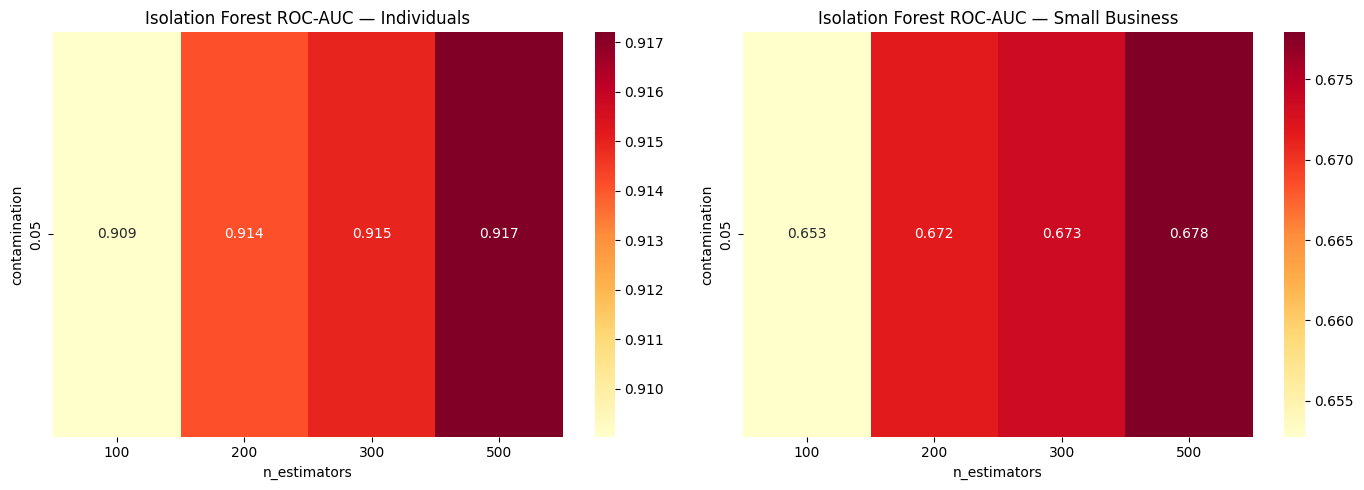

In [24]:
# Heatmap: contamination vs n_estimators (averaged over other params)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in zip(axes,
                          [iso_results_ind, iso_results_bus],
                          ['Individuals', 'Small Business']):
    pivot = df.groupby(['contamination', 'n_estimators'])['roc_auc'].mean().unstack()
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'Isolation Forest ROC-AUC — {title}')

plt.tight_layout()
plt.savefig('iso_forest_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Best params for Isolation Forest
best_iso_ind = iso_results_ind.iloc[0].to_dict()
best_iso_bus = iso_results_bus.iloc[0].to_dict()

print('Best Isolation Forest — Individuals:', best_iso_ind)
print('Best Isolation Forest — Small Biz  :', best_iso_bus)

Best Isolation Forest — Individuals: {'n_estimators': 100, 'contamination': 0.05, 'max_samples': 0.5, 'max_features': 0.5, 'roc_auc': 0.9386951631046119, 'pr_auc': 0.13551231723274731}
Best Isolation Forest — Small Biz  : {'n_estimators': 300, 'contamination': 0.05, 'max_samples': 0.5, 'max_features': 0.8, 'roc_auc': 0.7027027027027027, 'pr_auc': 0.15935939593228593}


---
## 5. Evaluate Tuned Models on Full Dataset

In [26]:
# Retrain best Isolation Forest with optimal params and compare
def build_best_iso(best_row, X, y, label):
    params = {k: v for k, v in best_row.items()
              if k not in ('roc_auc', 'pr_auc')}
    model = IsolationForest(**params, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X)
    scores = -model.decision_function(X)
    print(f'\n=== {label} ===')
    print(f'ROC-AUC          : {roc_auc_score(y, scores):.4f}')
    print(f'Average Precision: {average_precision_score(y, scores):.4f}')
    return model

best_iso_ind_model = build_best_iso(best_iso_ind, X_ind, y_ind, 'Isolation Forest — Individuals')
best_iso_bus_model = build_best_iso(best_iso_bus, X_bus, y_bus, 'Isolation Forest — Small Business')


=== Isolation Forest — Individuals ===
ROC-AUC          : 0.9387
Average Precision: 0.1355

=== Isolation Forest — Small Business ===
ROC-AUC          : 0.7027
Average Precision: 0.1594


In [27]:

def precision_at_k(model, X, y, k, label):
    scores = -model.decision_function(X)
    top_k_idx = np.argsort(scores)[-k:]
    y_top_k = np.array(y)[top_k_idx]
    p_at_k = y_top_k.sum() / k
    n_fraud_caught = int(y_top_k.sum())
    n_total_fraud = int(y.sum())
    print(f'[{label}] P@{k}: {p_at_k:.4f}  ({n_fraud_caught}/{k} flagged are fraud | {n_fraud_caught}/{n_total_fraud} total fraudsters caught)')

print('=== Precision @ K — Isolation Forest ===\n')

# Individuals
for k in [10, 25, 50, 100]:
    precision_at_k(best_iso_ind_model, X_ind, y_ind, k, 'Individuals')

print()

# Small Business
for k in [5, 10, 20]:
    precision_at_k(best_iso_bus_model, X_bus, y_bus, k, 'Small Biz')


=== Precision @ K — Isolation Forest ===

[Individuals] P@10: 0.2000  (2/10 flagged are fraud | 2/6 total fraudsters caught)
[Individuals] P@25: 0.1200  (3/25 flagged are fraud | 3/6 total fraudsters caught)
[Individuals] P@50: 0.0800  (4/50 flagged are fraud | 4/6 total fraudsters caught)
[Individuals] P@100: 0.0400  (4/100 flagged are fraud | 4/6 total fraudsters caught)

[Small Biz] P@5: 0.2000  (1/5 flagged are fraud | 1/4 total fraudsters caught)
[Small Biz] P@10: 0.1000  (1/10 flagged are fraud | 1/4 total fraudsters caught)
[Small Biz] P@20: 0.0500  (1/20 flagged are fraud | 1/4 total fraudsters caught)


---
## 6. Best Hyperparameters Summary

In [28]:
summary = {
    'Model': [
        'Isolation Forest (Individuals)',
        'Isolation Forest (Small Biz)',
    ],
    'Best Params': [
        str({k: v for k, v in best_iso_ind.items() if k not in ('roc_auc', 'pr_auc')}),
        str({k: v for k, v in best_iso_bus.items() if k not in ('roc_auc', 'pr_auc')}),
    ],
    'ROC-AUC': [
        round(best_iso_ind['roc_auc'], 4),
        round(best_iso_bus['roc_auc'], 4),
    ]
}

pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(summary))

,Model,Best Params,ROC-AUC
0,Isolation Forest (Individuals),"{'n_estimators': 100, 'contamination': 0.05, 'max_samples': 0.5, 'max_features': 0.5}",0.9387
1,Isolation Forest (Small Biz),"{'n_estimators': 300, 'contamination': 0.05, 'max_samples': 0.5, 'max_features': 0.8}",0.7027
